# Ejercicio 1
Genere im´agenes utilizando los diferentes modelos de ruido: normal, uniforme,
sal y pimienta, impulsivo unimodal y exponencial. etc.).
Estudie la distribuci´on obtenida analizando el histograma.
Adapte sus funciones para que los ruidos gaussiano, uniforme y exponencial tengan su media en 0 (cero).
2. Genere una imagen (600 × 600px) que contenga 3 franjas verticales (600 × 200
px) de grises constantes, utilizando un gris claro (≈ 180), uno medio (≈ 120) y
uno oscuro (≈ 60), y visualice el histograma.
Sume los ruidos generado previamente, con valor medio en cero, y vizualice los
histogramas.
Var´ıe los par´ametros del ruido (media, desv´ıo, etc.) y verifique los efectos en el
histograma para cada porci´on de grises constantes

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

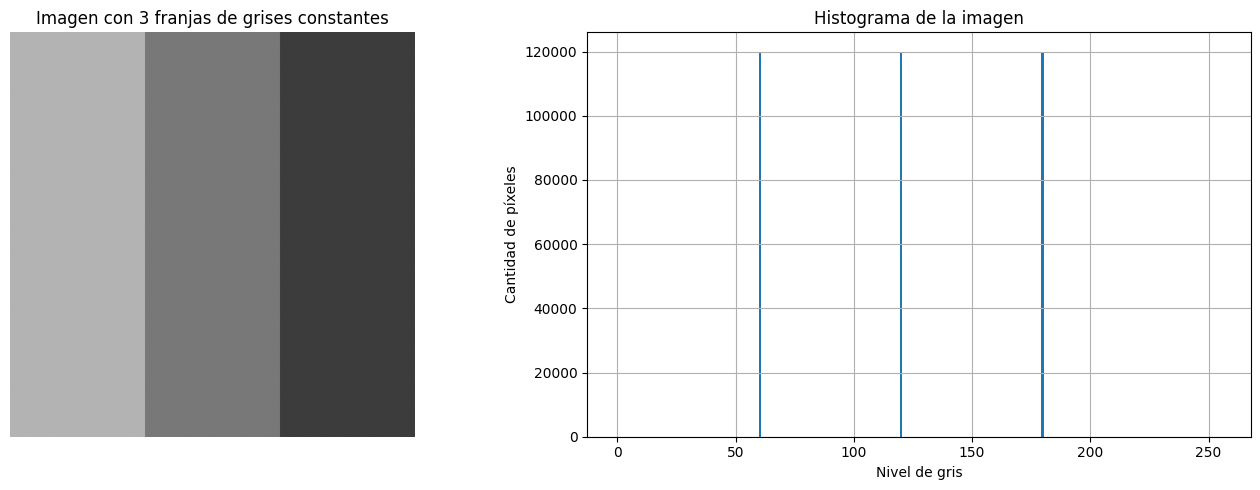

In [15]:
img = np.zeros((600, 600), dtype=np.uint8)
img[:, 0:200]   = 180
img[:, 200:400] = 120
img[:, 400:600] = 60

fig, ax = plt.subplots(1, 2, figsize=(14,5))

ax[0].imshow(img, cmap='gray', vmin=0, vmax=255)
ax[0].set_title("Imagen con 3 franjas de grises constantes")
ax[0].axis('off')


ax[1].hist(img.ravel(), bins=256, range=(0,255))
ax[1].set_title("Histograma de la imagen")
ax[1].set_xlabel("Nivel de gris")
ax[1].set_ylabel("Cantidad de píxeles")
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [16]:
def ruido_gaussiano(imagen, media=0, sigma=20):
    ruido = np.random.normal(media, sigma, imagen.shape)
    salida = imagen + ruido
    return np.clip(salida, 0, 255)

def ruido_uniforme(imagen, a=30):
    ruido = np.random.uniform(-a, a, imagen.shape)
    salida = imagen + ruido
    return np.clip(salida, 0, 255)

def ruido_exponencial(imagen, scale=20):
    ruido = np.random.exponential(scale, imagen.shape)
    ruido = ruido - scale     # centrar en cero
    salida = imagen + ruido
    return np.clip(salida, 0, 255)

def ruido_sal_pimienta(imagen, prob=0.03):
    salida = imagen.copy()
    rnd = np.random.rand(*imagen.shape)
    salida[rnd < prob/2] = 0
    salida[rnd > 1 - prob/2] = 255
    return salida

def ruido_impulsivo_unimodal(imagen, prob=0.03,amplitud=80):

    #solo pimienta
    
    salida = imagen.copy()
    mascara = np.random.rand(*imagen.shape) < prob
    salida[mascara] = 0
    return salida


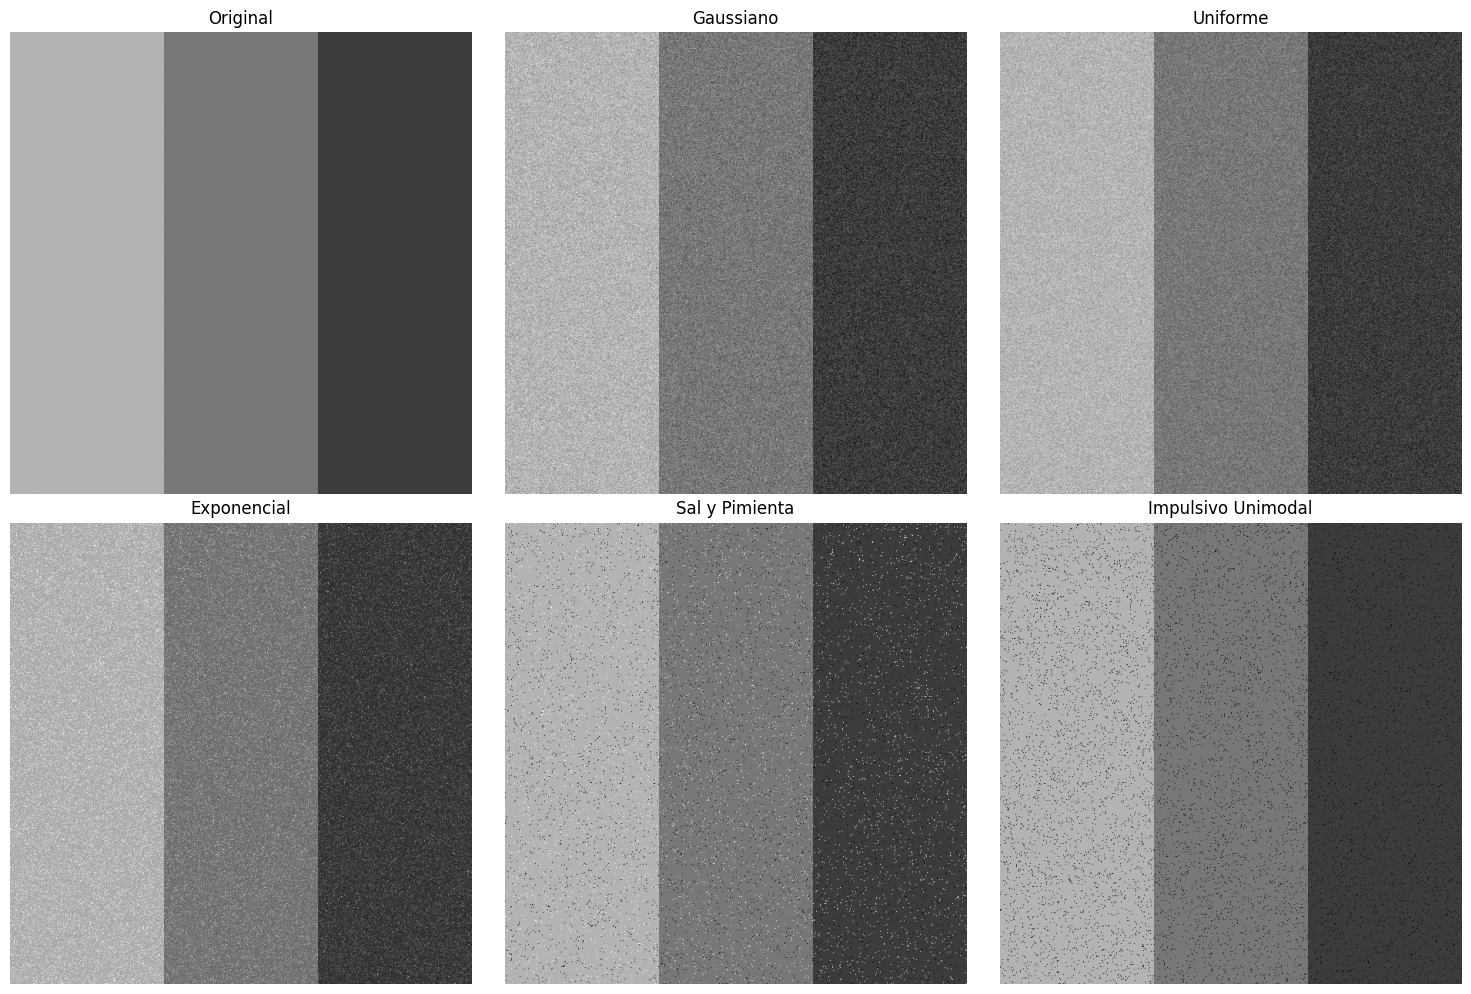

In [17]:
img_gauss = ruido_gaussiano(img, sigma=20)
img_uniforme = ruido_uniforme(img, a=30)
img_exponencial = ruido_exponencial(img, scale=20)
img_sp = ruido_sal_pimienta(img, prob=0.03)
img_impulsivo = ruido_impulsivo_unimodal(img,prob=0.03,amplitud=100)

imagenes = [
    ("Original", img),
    ("Gaussiano", img_gauss),
    ("Uniforme", img_uniforme),
    ("Exponencial", img_exponencial),
    ("Sal y Pimienta", img_sp),
    ("Impulsivo Unimodal", img_impulsivo)
]

fig, ax = plt.subplots(2, 3, figsize=(15,10))
ax = ax.ravel()

for i, (titulo, imagen) in enumerate(imagenes):

    ax[i].imshow(imagen, cmap='gray', vmin=0, vmax=255)
    ax[i].set_title(titulo)
    ax[i].axis('off')

plt.tight_layout()
plt.show()


Ahora vamos a analizar los histogramas de grises para ver si podemos estimar las distirbuciones de los errores.

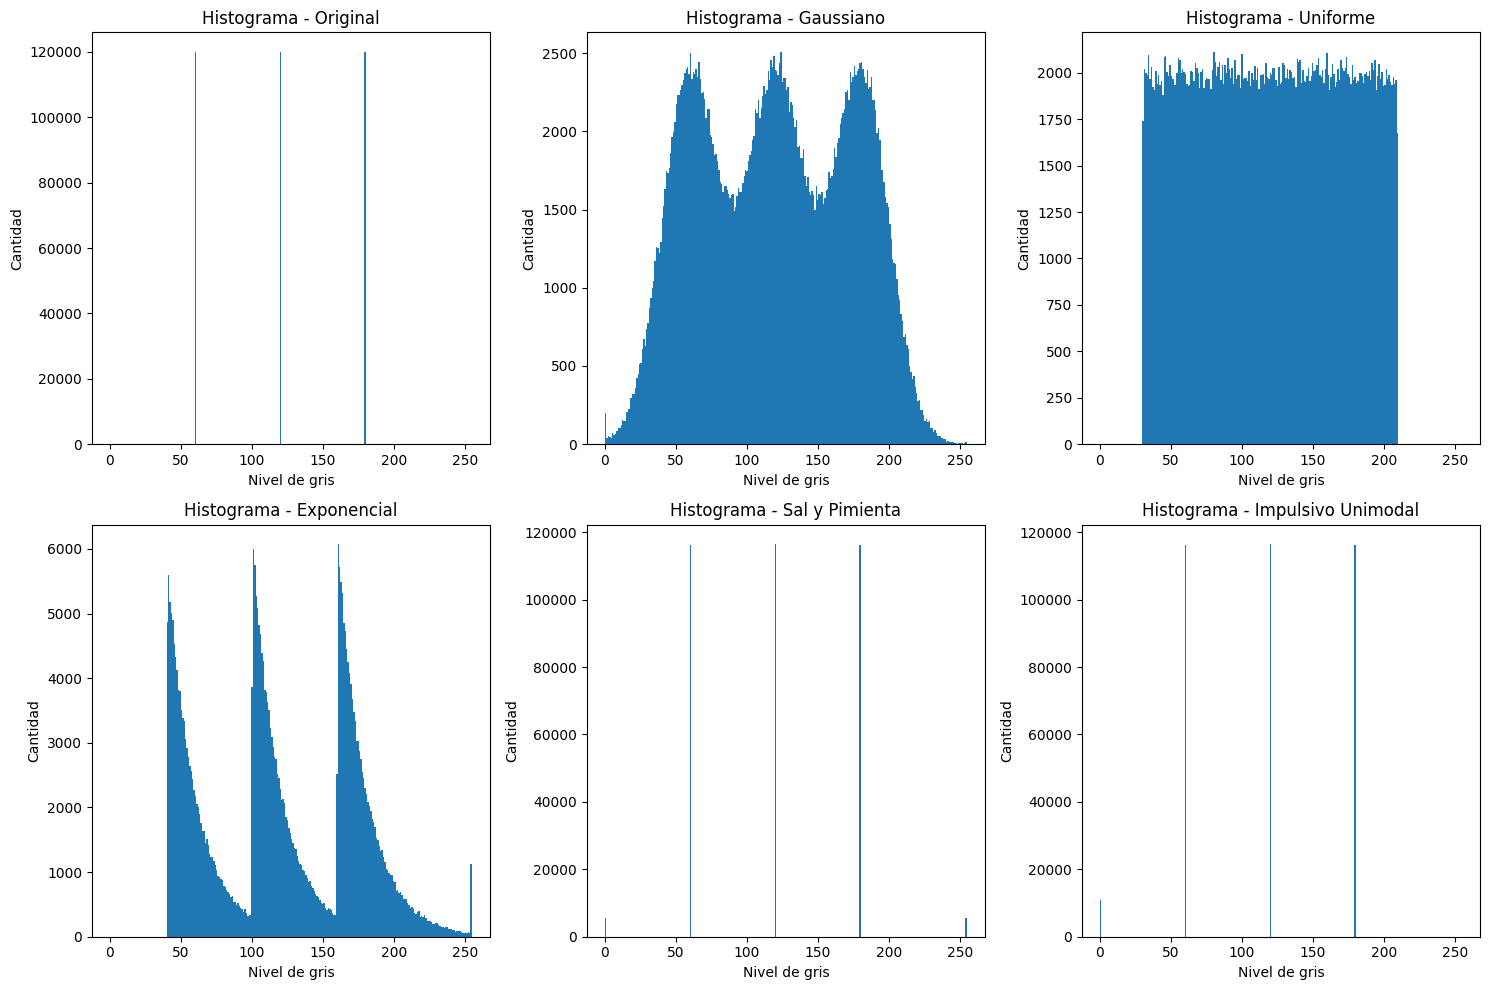

In [18]:
fig, ax = plt.subplots(2, 3, figsize=(15,10))

ax = ax.ravel()

for i, (titulo, imagen) in enumerate(imagenes):

    ax[i].hist(imagen.ravel(),
               bins=256,
               range=(0,255))

    ax[i].set_title(f"Histograma - {titulo}")
    ax[i].set_xlabel("Nivel de gris")
    ax[i].set_ylabel("Cantidad")

plt.tight_layout()
plt.show()

Como se puede apreciar, se ven en las distribuciones del histograma los errores. Esto se puede entender en un contexto de imagen, el analisis de los histogramas de una region homogenea.

- al sumarle ruido si se excede clipea.